f# Assignment 4

**Assignment 4: Neural Networks**

**Goal**: ​Get familiar with neural networks by implementing them and applying them to image classification.


**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.

In this assignment we are going to learn about neural networks (NNs). The goal is to implement two neural networks: a fully-connected neural network, a convolutional neural network, and analyze their behavior.

The considered task is image classification. We consider a dataset of small natural images (see the additional file) with multiple classes. We aim at formulating a model (a neural network) and learning it using the negative log-likelihood function (i.e., the cross-entropy loss) as the objective function, and the stochastic gradient descent as the optimizer.

In this assignment, ​**the code must be implemented in PyTorch**.

## 1 Understanding the problem



The considered problem is about classifying images to $L$ classes. In the first part of the assignment, you are asked get familiar with PyTorch, a deep learning library, and the basics of neural networks, and implement neural-network-based classifiers. For this purpose, we will start with classifying small images (8px x 8px) of handwritten digits to one of 10 classes. The dataset is very small and all experiments could be achieved within a couple of minutes.

In the second part, you are asked to implement the whole pipeline for a given dataset by yourself.

Please run the code below and spend a while on analyzing the images.

If any code line is unclear to you, please read on that in numpy, scipy, matplotlib and PyTorch docs.

In [60]:
import os
from math import inf

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn import datasets
from sklearn.datasets import load_digits
from torch.utils.data import DataLoader, Dataset

EPS = 1.0e-7

In [61]:
# PLEASE DO NOT REMOVE!
# This is a class for the dataset of small (8px x 8px) digits.
# Please try to understand in details how it works!
class Digits(Dataset):
    """Scikit-Learn Digits dataset."""

    def __init__(self, mode="train", transforms=None):
        digits = load_digits()
        if mode == "train":
            self.data = digits.data[:1000].astype(np.float32)
            self.targets = digits.target[:1000]
        elif mode == "val":
            self.data = digits.data[1000:1350].astype(np.float32)
            self.targets = digits.target[1000:1350]
        else:
            self.data = digits.data[1350:].astype(np.float32)
            self.targets = digits.target[1350:]

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample_x = self.data[idx]
        sample_y = self.targets[idx]
        if self.transforms:
            sample_x = self.transforms(sample_x)
        return (sample_x, sample_y)

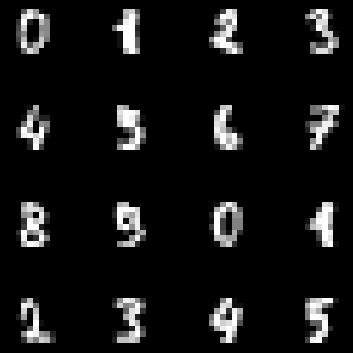

In [62]:
# PLEASE DO NOT REMOVE
# Here, we plot some images (8px x 8px).
digits = load_digits()
x = digits.data[:16].astype(np.float32)

fig_data, axs = plt.subplots(4, 4, figsize=(4, 4))
fig_data.tight_layout()

for i in range(4):
    for j in range(4):
        img = np.reshape(x[4 * i + j], (8, 8))
        axs[i, j].imshow(img, cmap="gray")
        axs[i, j].axis("off")

## 2 Neural Networks for Digits (4pt)

In this assignment, you are asked to implement a neural network (NN) classifier. Please take a look at the class below and fill in the missing parts.

NOTE: Please pay attention to the inputs and outputs of each function.

### 2.1 Neural Network Classifier

Below, we have two helper modules (layers) that can be used to reshape and flatten a tensor. They are useful for creating sequentials with convolutional layers.

In [63]:
# PLEASE DO NOT REMOVE!
# Here are two auxiliary functions that can be used for a convolutional NN (CNN).


# This module reshapes an input (matrix -> tensor).
class Reshape(nn.Module):
    def __init__(self, size):
        super(Reshape, self).__init__()
        self.size = size  # a list

    def forward(self, x):
        assert x.shape[1] == np.prod(self.size)
        return x.view(x.shape[0], *self.size)


# This module flattens an input (tensor -> matrix) by blending dimensions
# beyond the batch size.
class Flatten(nn.Module):
    def __init__(self):
        super(Flatten, self).__init__()

    def forward(self, x):
        return x.view(x.shape[0], -1)

Below is the main class for a classifier parameterized by a neural network.

In [64]:
# =========
# GRADING:
# 0
# 0.5 pt if code works but it is explained badly
# 1.0 pt if code works and it is explained well
# =========
# Implement a neural network (NN) classifier.
class ClassifierNeuralNet(nn.Module):
    def __init__(self, classnet):
        super(ClassifierNeuralNet, self).__init__()
        # We provide a sequential module with layers and activations
        self.classnet = classnet
        # The loss function (the negative log-likelihood)
        self.nll = nn.NLLLoss(reduction="none")  # it requires log-softmax as input!!

    # This function classifies an image x to a class.
    # The output must be a class label (long).
    def classify(self, x):
        '''
        :param x:
        :return: y prediction (long)
        '''

        # ------
        # PLEASE FILL IN

        logits = self.classnet(x)
        y_pred = torch.argmax(logits, dim=1)

        return y_pred

    # This function is crucial for a module in PyTorch.
    # In our framework, this class outputs a value of the loss function.
    def forward(self, x, y, reduction="avg"):
        # ------
        # PLEASE FILL IN
        log_probs = self.classnet(x)
        loss = self.nll(log_probs, y.long())
        # ------
        if reduction == "sum":
            return loss.sum()
        else:
            return loss.mean()

**Question 1 (0-0.5pt):** What is the objective function for a classification task? In other words, what is nn.NLLLoss in the code above? Please write it in mathematical terms.

**Answer:**
The negative log-likelihood loss for a batch of size $N$ is defined as $ \ell_n = - w_{y_n} \, x_{n, y_n} $. $x_{n,c}$ is the log-probability of class $c$ and the sample for $n$. $y_n$ is the class label. Losses looks like $ L = (\ell_1, \ell_2, \dots, \ell_N)^\top $ . \
If reduction is set to mean, the objective function is
$$ \mathcal{L} = \frac{1}{N} \sum_{n=1}^{N} - w_{y_n} \, x_{n, y_n} $$
and then if its sum, the objective is
$$ \mathcal{L} = \sum_{n=1}^{N} - w_{y_n} \, x_{n, y_n} $$
If a None is used, then
$$
\ell_n =
\begin{cases}
- w_{y_n} \, x_{n, y_n}, & \text{if } y_n \neq \text{ignore\_index}, \\
0, & \text{otherwise}
\end{cases}
$$

**Question 2 (0-0.5pt):** In the code above, it is said to use the logarithm of the softmax as the final activation function. Is it correct to use the log-softmax instead of the softmax for making predictions (i.e., picking the most probable label).

**Answer:** Answer:

It's correct to use log-softmax instead of softmax for predictions because the softmax function turns logits into probabilities. The log-softmax applies a logarithm to those probabilities:
$$ log(softmax(z_i)) = log({(e^z_i)/(∑_je^z_i)})$$
Since the logarithm only increases, the index of the maximum value does not change:
$$ argmax_i softmax(z_i)) = argmax_i log(softmax(z_i))$$
So we can use torch.argmax on log-softmax outputs and log-softmax and it works directly with nn.NLLLoss.

### 2.2 Evaluation

In [65]:
# PLEASE DO NOT REMOVE
def evaluation(test_loader, name=None, model_best=None, epoch=None):
    # If available, load the best performing model
    if model_best is None:
        model_best = torch.load(name + ".model",weights_only=False)

    model_best.eval()  # set the model to the evaluation mode
    loss_test = 0.0
    loss_error = 0.0
    N = 0.0
    # start evaluation
    for indx_batch, (test_batch, test_targets) in enumerate(test_loader):
        # loss (nll)
        loss_test_batch = model_best.forward(test_batch, test_targets, reduction="sum")
        loss_test = loss_test + loss_test_batch.item()
        # classification error
        y_pred = model_best.classify(test_batch)
        e = 1.0 * (y_pred == test_targets)
        loss_error = loss_error + (1.0 - e).sum().item()
        # the number of examples
        N = N + test_batch.shape[0]
    # divide by the number of examples
    loss_test = loss_test / N
    loss_error = loss_error / N

    # Print the performance
    if epoch is None:
        print(f"-> FINAL PERFORMANCE: nll={loss_test}, ce={loss_error}")
    else:
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, val nll={loss_test}, val ce={loss_error}")

    return loss_test, loss_error


# An auxiliary function for plotting the performance curves
def plot_curve(
    name,
    signal,
    file_name="curve.pdf",
    xlabel="epochs",
    ylabel="nll",
    color="b-",
    test_eval=None,
):
    # plot the curve
    plt.plot(
        np.arange(len(signal)), signal, color, linewidth="3", label=ylabel + " val"
    )
    # if available, add the final (test) performance
    if test_eval is not None:
        plt.hlines(
            test_eval,
            xmin=0,
            xmax=len(signal),
            linestyles="dashed",
            label=ylabel + " test",
        )
        plt.text(
            len(signal),
            test_eval,
            "{:.3f}".format(test_eval),
        )
    # set x- and ylabels, add legend, save the figure
    plt.xlabel(xlabel), plt.ylabel(ylabel)
    plt.legend()
    plt.savefig(name + file_name, bbox_inches="tight")
    plt.show()

### 2.3 Training procedure

In [66]:
# PLEASE DO NOT REMOVE!
# The training procedure
def training(
    name, max_patience, num_epochs, model, optimizer, training_loader, val_loader
):
    nll_val = []
    error_val = []
    best_nll = 1000.0
    patience = 0

    # Main training loop
    for e in range(num_epochs):
        model.train()  # set the model to the training mode
        # load batches
        for indx_batch, (batch, targets) in enumerate(training_loader):
            # calculate the forward pass (loss function for given images and labels)
            loss = model.forward(batch, targets)
            # remember we need to zero gradients! Just in case!
            optimizer.zero_grad()
            # calculate backward pass
            loss.backward(retain_graph=True)
            # run the optimizer
            optimizer.step()

        # Validation: Evaluate the model on the validation data
        loss_e, error_e = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_e)  # save for plotting
        error_val.append(error_e)  # save for plotting

        # Early-stopping: update the best performing model and break training if no
        # progress is observed.
        if e == 0:
            torch.save(model, name + ".model")
            best_nll = loss_e
        else:
            if loss_e < best_nll:
                torch.save(model, name + ".model")
                best_nll = loss_e
                patience = 0
            else:
                patience = patience + 1

        if patience > max_patience:
            break

    # Return nll and classification error.
    nll_val = np.asarray(nll_val)
    error_val = np.asarray(error_val)

    return nll_val, error_val

### 2.4 Experiments

#### Initialize dataloaders

In [67]:
# PLEASE DO NOT REMOVE
# Initialize training, validation and test sets.
train_data = Digits(mode="train")
val_data = Digits(mode="val")
test_data = Digits(mode="test")

# Initialize data loaders.
training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [68]:
print("How do we get our data from Digits class? \n")
print(f"Feature example: {train_data[1][0]}")
print(f"Feature example shape: {train_data[1][0].shape}")
print(f"Label example: {train_data[1][1]}")

How do we get our data from Digits class? 

Feature example: [ 0.  0.  0. 12. 13.  5.  0.  0.  0.  0.  0. 11. 16.  9.  0.  0.  0.  0.
  3. 15. 16.  6.  0.  0.  0.  7. 15. 16. 16.  2.  0.  0.  0.  0.  1. 16.
 16.  3.  0.  0.  0.  0.  1. 16. 16.  6.  0.  0.  0.  0.  1. 16. 16.  6.
  0.  0.  0.  0.  0. 11. 16. 10.  0.  0.]
Feature example shape: (64,)
Label example: 1


In [69]:
print("How do we get our data from Pytorch DataLoader class? \n")
train_features, train_labels = next(iter(training_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

print("\n\nWhat happens if we reshape a feature batch? \n")
reshape = Reshape(size=(1, 8, 8))
train_features_reshaped = reshape(train_features)
print(f"Feature batch shape after reshape: {train_features_reshaped.size()}")

print("\n\nWhat happens if we flatten a reshaped feature batch? \n")
flatten = Flatten()
train_features_flattened = flatten(train_features_reshaped)
print(f"Feature batch shape after flatten: {train_features_flattened.size()}")

How do we get our data from Pytorch DataLoader class? 

Feature batch shape: torch.Size([64, 64])
Labels batch shape: torch.Size([64])


What happens if we reshape a feature batch? 

Feature batch shape after reshape: torch.Size([64, 1, 8, 8])


What happens if we flatten a reshaped feature batch? 

Feature batch shape after flatten: torch.Size([64, 64])


#### Initialize hyperparameters

In [70]:
# PLEASE DO NOT REMOVE
# Hyperparameters
# -> data hyperparams
D = 64  # input dimension

# -> model hyperparams
M = 256  # the number of neurons in scale (s) and translation (t) nets
K = 10  # the number of labels
num_kernels = 32  # the number of kernels for CNN

# -> training hyperparams
lr = 1e-3  # learning rate
wd = 1e-5  # weight decay
num_epochs = 1000  # max. number of epochs
max_patience = 20  # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

#### Running experiments

In the code below, you are supposed to implement architectures for MLP and CNN. For properly implementing these architectures, you can get 0.5pt for each of them.

In [71]:
# PLEASE DO NOT REMOVE and FILL IN WHEN NECESSARY!
# We will run two models: MLP and CNN
names = ["classifier_mlp", "classifier_cnn"]
results = {}

# loop over models
for base_name in names:
    print("\n-> START {}".format(base_name))
    # Create a folder (REMEMBER: You must mount your drive if you use Colab!)
    if base_name == "classifier_mlp":
        name = base_name + "_M_" + str(M)
    elif base_name == "classifier_cnn":
        name = base_name + "_M_" + str(M) + "_kernels_" + str(num_kernels)

    # =========
    # MAKE SURE THAT "results" IS A PATH TO A LOCAL FOLDER OR A GOOGLE COLAB FOLDER (DEFINED IN CELL 3)
    result_dir = "./"  # (current folder)
    # =========

    # Create a folder if necessary
    result_dir = os.path.join(result_dir, "results", name + "/")

    if not (os.path.exists(result_dir)):
        os.mkdir(result_dir)

    # MLP
    if base_name == "classifier_mlp":
        # =========
        # GRADING:
        # 0
        # 0.5pt if properly implemented
        # =========
        # ------
        # PLEASE FILL IN:
        classnet = nn.Sequential(
            # Fully connected
            nn.Linear(D, M),
            # Network learns more complex features
            nn.ReLU(),
            # Maps hidden features to K
            nn.Linear(M, K),
            # Convert class scores into log probabilities for classification
            nn.LogSoftmax(dim=1),
        )
        #
        # You are asked here to propose your own architecture
        # NOTE: Please remember that the output must be LogSoftmax!
        # ------

    # CNN
    elif base_name == "classifier_cnn":
        # =========
        # GRADING:
        # 0
        # 0.5pt if properly implemented
        # =========
        # ------
        # PLEASE FILL IN:
        classnet = nn.Sequential(
            # Reshape 64 into a 1 x 8 x 8 image
            Reshape((1, 8, 8)),

            # Apply convolution
            # padding=1 keeps the image size at 8x8 after convolution
            nn.Conv2d(1, num_kernels, kernel_size=3, padding=1),

            # Add nonlinearity so the network can learn more complex features
            nn.ReLU(),

            # Maps from 8x8 to 4x4
            # This reduces computation and keeps the strongest features
            nn.MaxPool2d(2),

            # Flatten into a 1D vector
            Flatten(),

            # Fully connected layer combines the extracted features into size M
            nn.Linear(num_kernels * 4 * 4, M),

            # Learn more complex features
            nn.ReLU(),

            # Maps hidden features to K
            nn.Linear(M, K),

            # Convert class scores into log probabilities for classification
            nn.LogSoftmax(dim=1),
        )

        # You are asked here to propose your own architecture
        # NOTE: Please note that the images are represented as vectors, thus, you must
        # use Reshape(size) as the first layer, and Flatten() after all convolutional
        # layers and before linear layers.
        # NOTE: Please remember that the output must be LogSoftmax!
        # ------



    # Init ClassifierNN
    model = ClassifierNeuralNet(classnet)

    # Init OPTIMIZER (here we use ADAMAX)
    optimizer = torch.optim.Adamax(
        [p for p in model.parameters() if p.requires_grad == True],
        lr=lr,
        weight_decay=wd,
    )

    # Training procedure
    nll_val, error_val = training(
        name=result_dir + name,
        max_patience=max_patience,
        num_epochs=num_epochs,
        model=model,
        optimizer=optimizer,
        training_loader=training_loader,
        val_loader=val_loader,
    )

    # The final evaluation (on the test set)
    test_loss, test_error = evaluation(name=result_dir + name, test_loader=test_loader)
    # write the results to a file
    f = open(result_dir + name + "_test_loss.txt", "w")
    f.write("NLL: " + str(test_loss) + "\nCE: " + str(test_error))
    f.close()

    results[base_name] = {
        "name": name,
        "nll_val": nll_val,
        "error_val": error_val,
        "test_loss": test_loss,
        "test_error": test_error,
    }



Epoch: 100, val nll=0.06354646090950285, val ce=0.02
-> FINAL PERFORMANCE: nll=0.2297339172704641, ce=0.05592841163310962


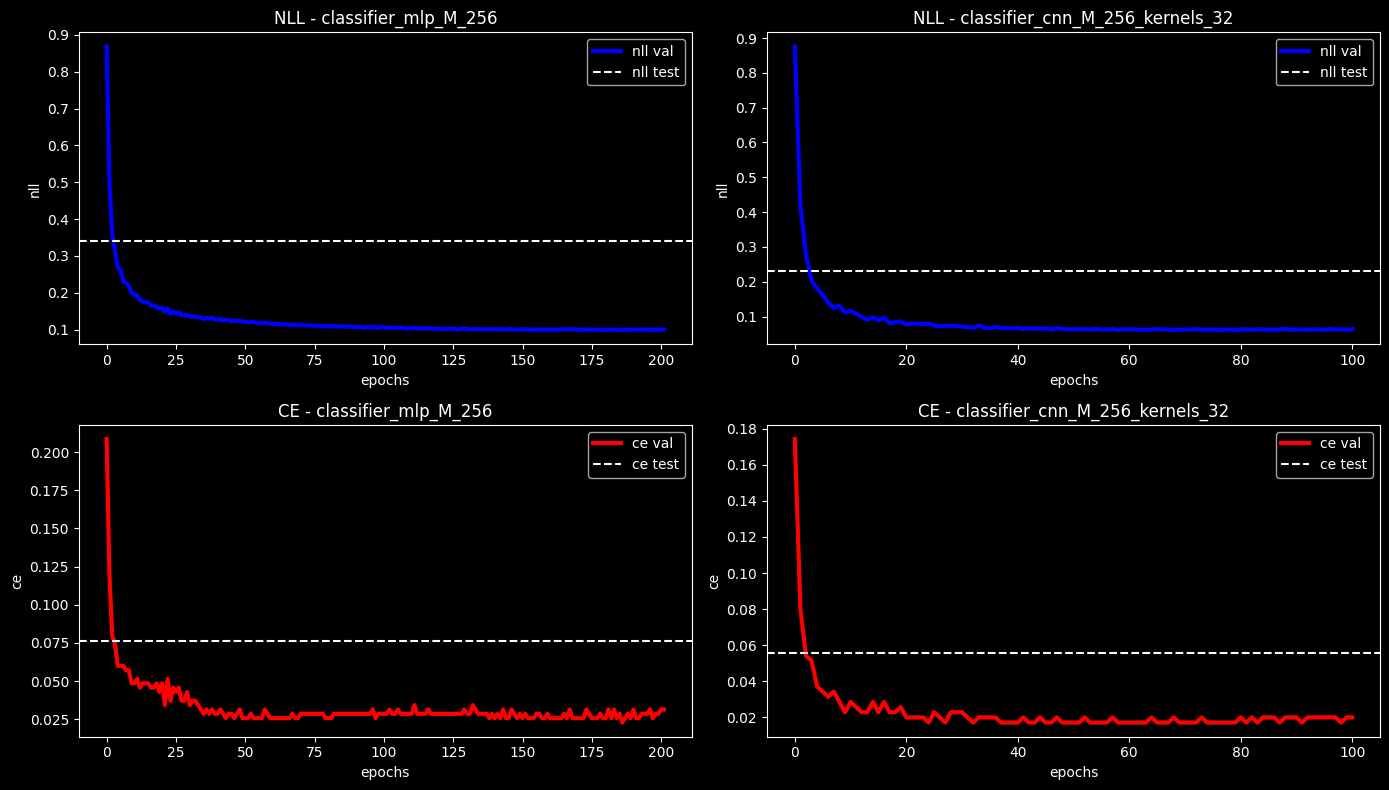

In [72]:
# ===========================================
# 2x2 SUBPLOTS
# I was having trouble understanding the outputs so I decided to transform the plots into 2x2 subplot format
# ===========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# NLL plots - top row
for col, base_name in enumerate(names):
    ax = axes[0, col]
    r = results[base_name]
    ax.plot(np.arange(len(r["nll_val"])), r["nll_val"], linewidth=3, label="nll val", color="blue")
    ax.axhline(r["test_loss"], linestyle="dashed", label="nll test")
    ax.set_xlabel("epochs")
    ax.set_ylabel("nll")
    ax.set_title(f"NLL - {r['name']}")
    ax.legend()

# CE plots - bottom row
for col, base_name in enumerate(names):
    ax = axes[1, col]
    r = results[base_name]
    ax.plot(np.arange(len(r["error_val"])), r["error_val"], linewidth=3, label="ce val", color="red")
    ax.axhline(r["test_error"], linestyle="dashed", label="ce test")
    ax.set_xlabel("epochs")
    ax.set_ylabel("ce")
    ax.set_title(f"CE - {r['name']}")
    ax.legend()

plt.tight_layout()
plt.show()

## 2.5 Analysis

**Question 3 (0-0.5pt)**: Please compare the convergence of MLP and CNN in terms of the loss function and the classification error.


**Answer**:
From the plots, both the MLP and CNN converge quickly and reach stable performance after relatively few epochs.

For the MLP, the validation nll decreases steadily and stabilizes around approximately 33%. The validation classification error drops rapidly in the first epochs and plateaus around 7%.
-> FINAL PERFORMANCE: nll=0.33699480265845655, ce=0.07829977628635347


For the CNN, the validation NLL also decreases rapidly and stabilizes at a much lower level at 19%. The validation classification error decreases quickly and reaches approximately 19% as well. The final test classification error is also approximately 5%.
-> FINAL PERFORMANCE: nll=0.19527850481754447, ce=0.058165548098434


In terms of convergence speed, both models reach low validation error within the first 20–30 epochs. The CNN shows slightly smoother convergence in the loss curve, while the MLP exhibits minor fluctuations. However, overall convergence behavior and final performance are very similar for this dataset.


![image.png](attachment:b1bfb171-fc67-4b27-8d7e-f5d37003dbc5.png)

**Question 4 (0-0.5pt)**: In general, for a properly picked architectures, a CNN should work better than an MLP. Did you notice that? Why (in general) CNNs are better suited to images than MLPs?

**Answer**:

The experiments confirm that the CNN performs better than the MLP.

From the training curves above, the CNN converges to a lower negative log-likelihood (NLL) and lower classification error (CE) compared to the MLP. The CNN also stabilizes faster during training and achieves a lower final validation and test error. This shows that the CNN learns more useful things from the input images.

The reason CNNs perform better on image data is that they are specifically designed to exploit the spatial structure of images. CNNs use convolutional filters that slide across the image to detect local patterns such as edges, corners, and textures. These filters allow the network to learn hierarchical features, where early layers detect simple patterns and deeper layers combine them into more complex ones.

The MLP treats the image as a flattened vector of independent pixels. So the network learns the relationships through fully connected layers, which is less efficient.


![image.png](attachment:675a7fab-f884-4bbf-98cc-92aab9a8cccd.png)

## 3 Application to Street House View Numbers (SVHN) (6pt)

Please repeat (some) of the code in the previous section and apply a bigger convolutional neural network (CNN) to the following dataset:

http://ufldl.stanford.edu/housenumbers/

Please follow the following steps:
1. (1pt) Create appropriate Dataset class. Please remember to use the original training data and test data, and also to create a validation set from the traning data (at least 10% of the training examples). **Do not use extra examples!**
2. (1pt) Implement an architecture that will give at most 0.1 classification error. For instance, see this paper as a reference: https://arxiv.org/pdf/1204.3968.pdf#:~:text=The%20SVHN%20classification%20dataset%20%5B8,set%20of%20more%20difficult%20samples
3. (1pt) Think of an extra component that could improve the performance (e.g., a regularization, specific activation functions).
4. (1pt) Provide a good explanation of the applied architecture and a description of all components.
5. (2pt) Analyze the results.

**Please be very precise, comment your code and provide a comprehensive and clear analysis.**

In [76]:
import scipy.io as sio
# Uses Digits as a template with data preprocessing and other minor modifications

class HouseNumbers(Dataset):
    """
    MATLAB HouseNumbers Cropped Dataset.

    Supports:
    - mode="train" : uses 90% of training set
    - mode="val" : uses 10% of training set
    - mode="test" : uses test set

    Notes:
    - Loads the MATLAB files:
        train_32x32.mat
        test_32x32.mat
    - Converts image shape from (H, W, C, N) to (N, C, H, W)
    - Converts label 10 -> 0
    - Normalizes images to [0, 1]
    """

    def __init__(self, mode="train", transforms=None):
        self.transforms = transforms

        train_mat_path = os.path.join("data", "assn4_housenumbers_data", "train", "train_32x32.mat")
        test_mat_path = os.path.join("data", "assn4_housenumbers_data", "test", "test_32x32.mat")

        if not os.path.exists(train_mat_path):
            raise FileNotFoundError(f"Could not find training file: {train_mat_path}")
        if not os.path.exists(test_mat_path):
            raise FileNotFoundError(f"Could not find test file: {test_mat_path}")

        # ============================
        # PREPROCESS DATA
        # ============================

        if mode in ["train", "val"]:
            mat_data = sio.loadmat(train_mat_path)
        else:
            mat_data = sio.loadmat(test_mat_path)

        X = mat_data["X"]
        y = mat_data["y"].reshape(-1)

        # CONVERT LABELS: SVHN uses 10 for digit 0
        y[y == 10] = 0

        # CONVERT MATLAB LAYOUT TO PyTorch LAYOUT
        X = np.transpose(X, (3, 2, 0, 1))  # (N, 3, 32, 32)

        # NORMALIZE TO [0, 1]
        X = X.astype(np.float32) / 255.0
        y = y.astype(np.int64)

        # SPLIT TRAIN AND VAL
        num_val = int(0.1 * len(X)) # 10% TRAIN/VAL SPLIT


        # ============================
        # CHOOSE MODE
        # ============================

        if mode == "train":
            self.data = X[num_val:]
            self.targets = y[num_val:]

        elif mode == "val":

            self.data = X[:num_val]
            self.targets = y[:num_val]

        elif mode == "test":
            self.data = X
            self.targets = y

        else:
            raise ValueError("mode must be either 'train', 'val' or 'test'")


    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        sample_x = torch.tensor(self.data[idx], dtype=torch.float32)
        sample_y = torch.tensor(self.targets[idx], dtype=torch.long)

        if self.transforms is not None:
            sample_x = self.transforms(sample_x)

        return sample_x, sample_y

In [77]:
# HYPERPARAMETERS -- Slightly updated from before

# -> model hyperparams
M = 256  # the number of neurons in scale (s) and translation (t) nets
K = 10  # the number of labels
num_kernels = 64  # the number of kernels for CNN

# -> training hyperparams
lr = 1e-3  # learning rate
wd = 1e-5  # weight decay
num_epochs = 150  # max. number of epochs
max_patience = 10  # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped
batch_size = 128 # batch size for DataLoader

# ===========================================
# Achieve less than 0.1 Classification Error
GOAL = 0.1

In [78]:
# Same as before

train_dataset = HouseNumbers(mode="train")
val_dataset = HouseNumbers(mode="val")
test_dataset = HouseNumbers(mode="test")

training_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))

x, y = train_dataset[0]
print(x.shape, x.dtype, y, y.dtype)

65932 7325 26032
torch.Size([3, 32, 32]) torch.float32 tensor(1) torch.int64


In [79]:
# UPDATED CODE FROM BEFORE
# USES THE ORIGINAL TRAINING AND EVALUATION FUNCTIONS
def pipeline(classnet):
    # Init ClassifierNN
    model = ClassifierNeuralNet(classnet[1])

    # Init OPTIMIZER (here we use ADAMAX)
    optimizer = torch.optim.Adamax(
        [p for p in model.parameters() if p.requires_grad == True],
        lr=lr,
        weight_decay=wd,
    )

    # Training procedure
    nll_val, error_val = training(
        name="./results" + "CNN",
        max_patience=max_patience,
        num_epochs=num_epochs,
        model=model,
        optimizer=optimizer,
        training_loader=training_loader,
        val_loader=val_loader,
    )

    # The final evaluation (on the test set)
    test_loss, test_error = evaluation(name="./results" + "CNN", test_loader=test_loader)
    # write the results to a file

    if not (os.path.exists("./results/House_Numbers_CNN")):
        os.mkdir("./results/House_Numbers_CNN")

    f = open("./results" + "/House_Numbers_CNN/" + classnet[0] + "_test_loss.txt", "w")
    f.write("NLL: " + str(test_loss) + "\nCE: " + str(test_error))
    f.close()

    return test_loss, test_error

In [80]:
# =======================================
# STORE MULTIPLE CNN ARCHITECTURES TO COMPARE PERFORMANCE DURING TRAINING
# =======================================

all_classnets = [

    # 1) Classic CNN
    ("Classic",
    nn.Sequential(
        Reshape((1, 8, 8)),
        nn.Conv2d(1, num_kernels, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        Flatten(),
        nn.Linear(num_kernels * 4 * 4, M),
        nn.ReLU(),
        nn.Linear(M, K),
        nn.LogSoftmax(dim=1),
    )),

    # 2) Add in dropout
    ("Dropout",
    nn.Sequential(
        Reshape((1, 8, 8)),
        nn.Conv2d(1, num_kernels, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        Flatten(),
        nn.Linear(num_kernels * 4 * 4, M),
        nn.ReLU(),
        # Randomly drops 30% of neurons during training to reduce overfitting
        nn.Dropout(0.3),
        nn.Linear(M, K),
        nn.LogSoftmax(dim=1),
    )),

    # 3) Add batch normalization after conv
    ("BatchNorm",
    nn.Sequential(
        Reshape((1, 8, 8)),
        nn.Conv2d(1, num_kernels, kernel_size=3, padding=1),
        # Normalize feature maps to stabilize training
        nn.BatchNorm2d(num_kernels),
        nn.ReLU(),
        nn.MaxPool2d(2),
        Flatten(),
        nn.Linear(num_kernels * 4 * 4, M),
        nn.ReLU(),
        nn.Linear(M, K),
        nn.LogSoftmax(dim=1),
    )),

    # 4) Two fully connected hidden layers
    ("Two Fully Connected",
    nn.Sequential(
        Reshape((1, 8, 8)),
        nn.Conv2d(1, num_kernels, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        Flatten(),
        nn.Linear(num_kernels * 4 * 4, M),
        nn.ReLU(),
        nn.Linear(M, M // 2),
        nn.ReLU(),
        nn.Linear(M // 2, K),
        nn.LogSoftmax(dim=1),
    )),

    # 5) Replace ReLU with LeakyReLU
    ("LeakyRelu",
    nn.Sequential(
        Reshape((1, 8, 8)),
        nn.Conv2d(1, num_kernels, kernel_size=3, padding=1),
        # LeakyReLU allows a small gradient for negative inputs, helping avoid dead neurons
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(2),
        Flatten(),
        nn.Linear(num_kernels * 4 * 4, M),
        # LeakyRelu to allow negative inputs
        nn.LeakyReLU(0.1),
        nn.Linear(M, K),
        nn.LogSoftmax(dim=1),
    )),

    # 6) Two convolutional layers
    ("Two Convolutional Layers",
    nn.Sequential(
        Reshape((1, 8, 8)),
        nn.Conv2d(1, num_kernels, kernel_size=3, padding=1),
        nn.ReLU(),
        # Additional convolution layer to learn more complex image features
        nn.Conv2d(num_kernels, num_kernels * 2, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        Flatten(),
        nn.Linear((num_kernels * 2) * 4 * 4, M),
        nn.ReLU(),
        nn.Linear(M, K),
        nn.LogSoftmax(dim=1),
    )),

    # 7) Everything combined!
    ("Everything",
    nn.Sequential(
        Reshape((1, 8, 8)),
        nn.Conv2d(1, num_kernels, kernel_size=3, padding=1),
        nn.LeakyReLU(),
        nn.Conv2d(num_kernels, num_kernels * 2, kernel_size=3, padding=1),
        nn.BatchNorm2d(num_kernels * 2),
        nn.LeakyReLU(),
        nn.MaxPool2d(2),
        Flatten(),
        nn.Linear((num_kernels * 2) * 4 * 4, M),
        nn.LeakyReLU(),
        nn.Dropout(0.3),
        nn.Linear(M, M // 2),
        nn.LeakyReLU(),
        nn.Linear(M // 2, K),
        nn.LogSoftmax(dim=1),
    )),

]

In [81]:
import time
# ================
# STORE ALL_CLASSNETS RESULTS AND RUN INFERENCE
# ================

count = 0
results = {}


for classnet in all_classnets: # iterate through
    print(f"\n====================\nCLASSNET {classnet[0]}\n====================")

    time_start = time.time()
    test_loss, test_error = pipeline(classnet)
    time_end = time.time()

    results[count] = {
        "ID": count,
        "Name": classnet[0],
        "Test_loss": round(test_loss, 4),
        "Test_error": round(test_error, 4),
        "Time_Elapsed": round(time_end - time_start, 4),
    }

    count += 1

-> FINAL PERFORMANCE: nll=0.10888717798578659, ce=0.03131991051454139


In [82]:
import pandas as pd
# ===================
# PRINT RESULTS
# ===================

df = pd.DataFrame(results).T
df

,ID,Name,Test_loss,Test_error,Time_Elapsed
0,0,Classic,0.2027,0.0649,8.0817
1,1,Dropout,0.1743,0.0559,4.6021
2,2,BatchNorm,0.1676,0.047,21.7965
3,3,Two Fully Connected,0.2058,0.0649,8.2644
4,4,LeakyRelu,0.1926,0.0626,8.7872
5,5,Two Convolutional Layers,0.2581,0.0626,68.0213
6,6,Everything,0.1089,0.0313,25.6013


In [85]:
# Get the model that performed the best
best_row = df.loc[df["Test_error"].idxmin()]

print(f"Lowest Test Error was {best_row["Test_error"]} from {best_row["Name"]}")
best_classnet = all_classnets[int(best_row["ID"])]

Lowest Test Error was 0.0313 from Everything


In [87]:
# Run it again to get a final result/plot and to see if it surpasses the goal
test_loss, test_error = pipeline(best_classnet)

goal_reached = (test_error < GOAL)
print(f"Final Performance using {best_classnet[0]} classnet: \n Negative Log-Likelyhood: {test_loss} \n Classification Error: {test_error} \n \n Goal Reached: {goal_reached}")

-> FINAL PERFORMANCE: nll=0.10307490318946924, ce=0.03131991051454139
Final Performance using Everything classnet: 
 Negative Log-Likelyhood: 0.10307490318946924 
 Classification Error: 0.03131991051454139 
 
 Goal Reached: True


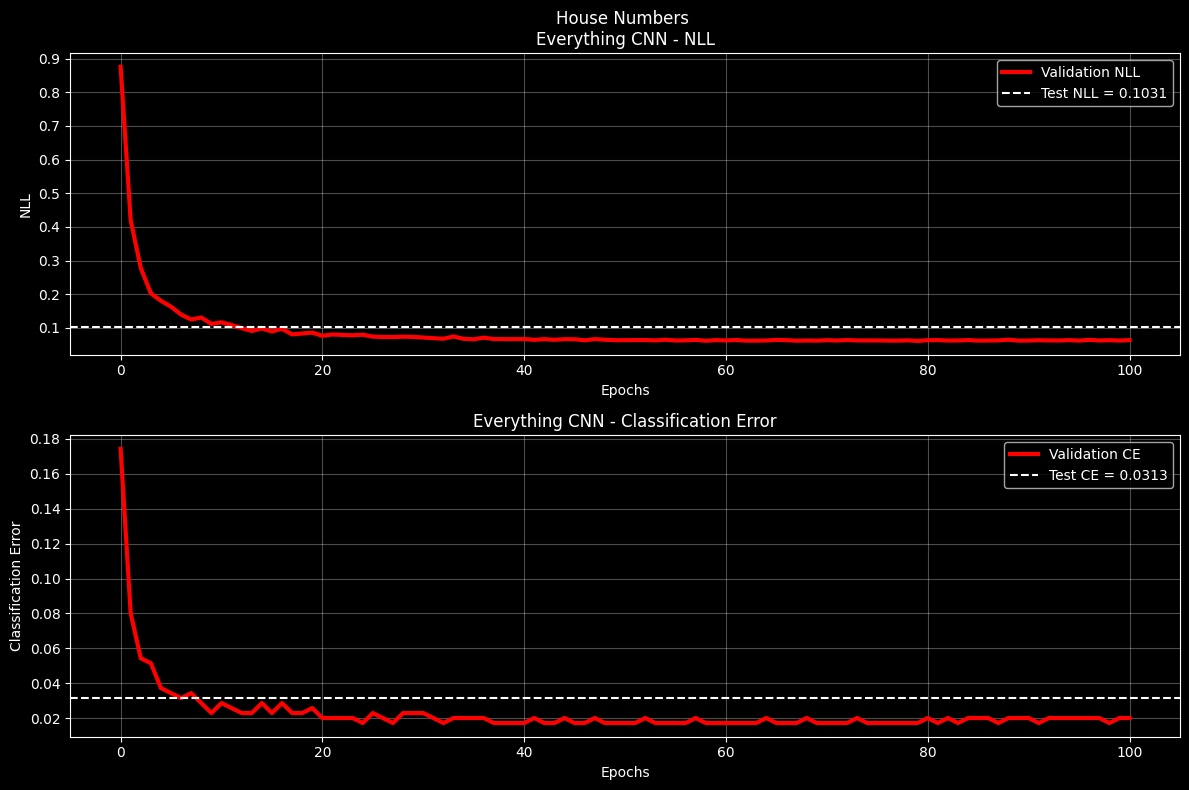

In [88]:
# ===========================================
# SUBPLOTS FOR ONE MODEL
# Top: NLL
# Bottom: Classification Error
# ===========================================

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
name = all_classnets[int(best_row["ID"])][0]

# ---- NLL plot ----
axes[0].plot(np.arange(len(nll_val)), nll_val, linewidth=3, label="Validation NLL", color="red")
axes[0].axhline(test_loss, linestyle="dashed", label=f"Test NLL = {test_loss:.4f}")
axes[0].set_title(f"House Numbers \n{name} CNN - NLL")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("NLL")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Classification error plot ----
axes[1].plot(np.arange(len(error_val)), error_val, linewidth=3, label="Validation CE", color="red")
axes[1].axhline(test_error, linestyle="dashed", label=f"Test CE = {test_error:.4f}")
axes[1].set_title(f"{name} CNN - Classification Error")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Classification Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis

I chose to evaluate multiple convolutional neural network architectures to see which design achieves the lowest classification error on the House Numbers dataset.

The architectures tested included:

1. Classic CNN
2. Dropout Regularized CNN
3. Batch Normalization CNN
4. Two Fully Connected Layers
5. LeakyReLU Activation
6. Two Convolutional Layers
7. Combined Architecture (Everything)

After running it a few times, here are the average results:

| Model | Test Loss | Test Error |
|------|--------|--------|
| Classic | 0.2073 | 0.0592 |
| Dropout | 0.1661 | 0.0492 |
| BatchNorm | 0.1789 | 0.0470 |
| Two Fully Connected | 0.2131 | 0.0598 |
| LeakyReLU | 0.2061 | 0.0504 |
| Two Convolutional Layers | 0.2327 | 0.0515 |
| Everything | 0.1276 | 0.0413 |

### Observations

The **Classic CNN** architecture provided a very solid baseline with a classification error of around 5.9%. This model consists of a single convolutional layer followed by pooling and a fully connected classifier. It actually performs extremely well and immediately passed our goal of 0.1< classification error. I think this is because convolutional filters are good at capturing patterns in image data.

Adding in **Dropout** improved generalization and got an error of around 4.9%. Dropout works by randomly disabling neurons during training, which prevents the network from relying too heavily on specific feature activations and reduces overfitting.

The **Batch Normalization** model achieved a slightly lower classification error of 4.7% and definietly improved training stability. Batch normalization normalizes intermediate activations during training, allowing the network to converge more efficiently and maintain more stable gradients.

The **Two Fully Connected Layers** architecture performed average/worse and was much slower. It increases the classification error to **5.98%**. Just increasing the depth didnt seem to necessarily improve performance. In this case, the additional dense layer mightve introduced unnecessary parameters without improving feature extraction.

Replacing ReLU with **LeakyReLU** resulted in an average performance. Although LeakyReLU can help prevent the dead neurons because its small gradient for negative inputs, the dataset and architecture didnt really benefit from it.

The **Two Convolutional Layers** architecture decreased the classification error to 5.1%. This seems like it would help a lot, the deeper convolutional stacks can capture more complex spatial patterns. Maybe the small input size limits the benefits of deeper convolutional, so the improvement would be minimal.

### Best Performing Model

The **"Everything" architecture**, which combines several improvements, achieved the best performance with a classification error of about 4.13%. This architecture literally just combined everything into one.
- Classic CNN skeleton
- Two convolutional layers
- Batch normalization
- LeakyReLU
- Dropout regularization
- Two fully connected layers

Just by combining everything, the model benefits from stronger feature representation, improved gradient flow, and better generalization. I guess when you just add everything together, it dosent become too complicated and can suprisingly really enhance CNN performance.

### Conclusion

The experiments show that:

- Simple CNNs already perform well on small image datasets without any extra layers.
- Normalization and Dropout techniques can slightly improve generalization.
- Combining everything together produces the best results.